In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')

df = pd.read_csv('kepler_clean.csv')
TARGET = 'koi_disposition'

COLOR_MAP = {
    'CONFIRMED': '#4CAF50',
    'CANDIDATE': '#F44336',
    'FALSE POSITIVE': '#FF9800'
}

FileNotFoundError: [Errno 2] No such file or directory: 'kepler_clean.csv'

SCATTER PLOT - RADIUS vs PERIOD

In [ ]:
fig = px.scatter(
    df,
    x='koi_period',
    y='koi_prad',
    color=TARGET,
    color_discrete_map=COLOR_MAP,
    hover_data=['koi_teq', 'koi_insol', 'koi_score'],
    log_x = True,
    log_y = True,
    title = 'Planet Radius vs Orbital Period (log-log scale)',
    labels = {
        'koi_period' : 'Orbital Period (days) - log scale',
        'koi_radius' : 'Planet Radius (Earth Radii) - log scale',
        TARGET : 'Disposition'
    },
    opacity = 1,
    template = 'plotly_dark'
)
fig.update_traces(marker=dict(size=4))
fig.write_html('p3_scatter_radius_period.html')
fig.show()

INTERACTIVE HISTOGRAM - PLANET RADIUS BY CLASS


In [ ]:
plot_df = df[['koi_prad', TARGET]].dropna()
plot_df = plot_df[plot_df['koi_prad'] > 0]

# Define bins manually on log scale
bins = np.logspace(
    np.log10(plot_df['koi_prad'].min()),
    np.log10(plot_df['koi_prad'].max()),
    81  # 80 bins
)

COLOR_MAP = {
    'CONFIRMED':      '#4CAF50',
    'FALSE POSITIVE': '#F44336',
    'CANDIDATE':      '#FF9800'
}

fig = go.Figure()

for disposition, color in COLOR_MAP.items():
    subset = plot_df[plot_df[TARGET] == disposition]['koi_prad']
    counts, edges = np.histogram(subset, bins=bins)
    fig.add_trace(go.Bar(
        x=edges[:-1],          # left edge of each bin
        y=counts,
        name=disposition,
        marker_color=color,
        opacity=0.75,
        width=np.diff(edges),  # each bar is exactly its bin width
        offset=0
    ))

fig.update_layout(
    barmode='overlay',
    title='Distribution of Planet Radius by Disposition Class',
    xaxis=dict(
        title='Planet Radius (Earth radii) — log scale',
        type='log'
    ),
    yaxis_title='Count',
    template='plotly_dark',
    legend_title='Disposition',
    bargap=0
)

fig.write_html('p3_histogram_radius.html')
fig.show()

INTERACTIVE BOX PLOTS - MULTIPLE FEATURES

In [ ]:
features_to_plot = {
    'koi_prad' : 'Planet Radius (Earth Radii)',
    'koi_insol' : 'Insolation Flux (Earth flux)',
    'koi_teq' : 'Equilibrium Temperature (K)',
    'koi_model_snr' : 'Signal-to-noise Ratio',
    'koi_score' : 'Disposition Score (0-1)',
    'koi_duration' : 'Transit Duration (hours)'
}

fig = make_subplots(rows=2, cols=3,
                    subplot_titles=list(features_to_plot.values()))

disp_groups = ['CONFIRMED', 'FALSE POSITIVE', 'CANDIDATE']
row_col = [(1,1),(1,2),(1,3),(2,1),(2,2),(2,3)]

for idx, (col, title) in enumerate(features_to_plot.items()):
    r, c = row_col[idx]
    for disp in disp_groups:
        subset = df[df[TARGET] == disp][col].dropna()
        fig.add_trace(
            go.Box(y=subset, name=disp, marker_color=COLOR_MAP[disp],
                   showlegend=(idx == 0), legendgroup=disp),
            row=r, col=c
        )

fig.update_layout(
    title_text = 'Key Features - Box Plots by Disposition Class',
    template = 'plotly_dark',
    height=700,
    boxmode='group'
)
fig.write_html('p3_boxplots_interactive.html')
fig.show()

HEATMAP CORRELATION MATRIX (INTERACTIVE Plotly)

In [ ]:
KEY_FEATURES = [
    'koi_period', 'koi_prad', 'koi_teq', 'koi_insol',
    'koi_model_snr', 'koi_steff', 'koi_slogg',
    'koi_srad', 'koi_score', 'koi_depth', 'koi_duration', 'koi_impact'
]

corr = df[KEY_FEATURES].corr().round(2)

fig = go.Figure(data=go.Heatmap(
    z = corr.values,
    x = corr.columns.tolist(),
    y = corr.columns.tolist(),
    colorscale = 'RdBu',
    zmid = 0,
    text = corr.values,
    texttemplate = '%{text}',
    textfont = {'size': 9},
    hoverongaps=False
))

fig.update_layout(
    title = 'Feature Correlation Heatmap',
    template = 'plotly_dark',
    height=600, width=750
)
fig.write_html('p3_correlation_heatmap.html')
fig.show()

PAIR PLOT - TOP FEATURES (seaborn Stats)

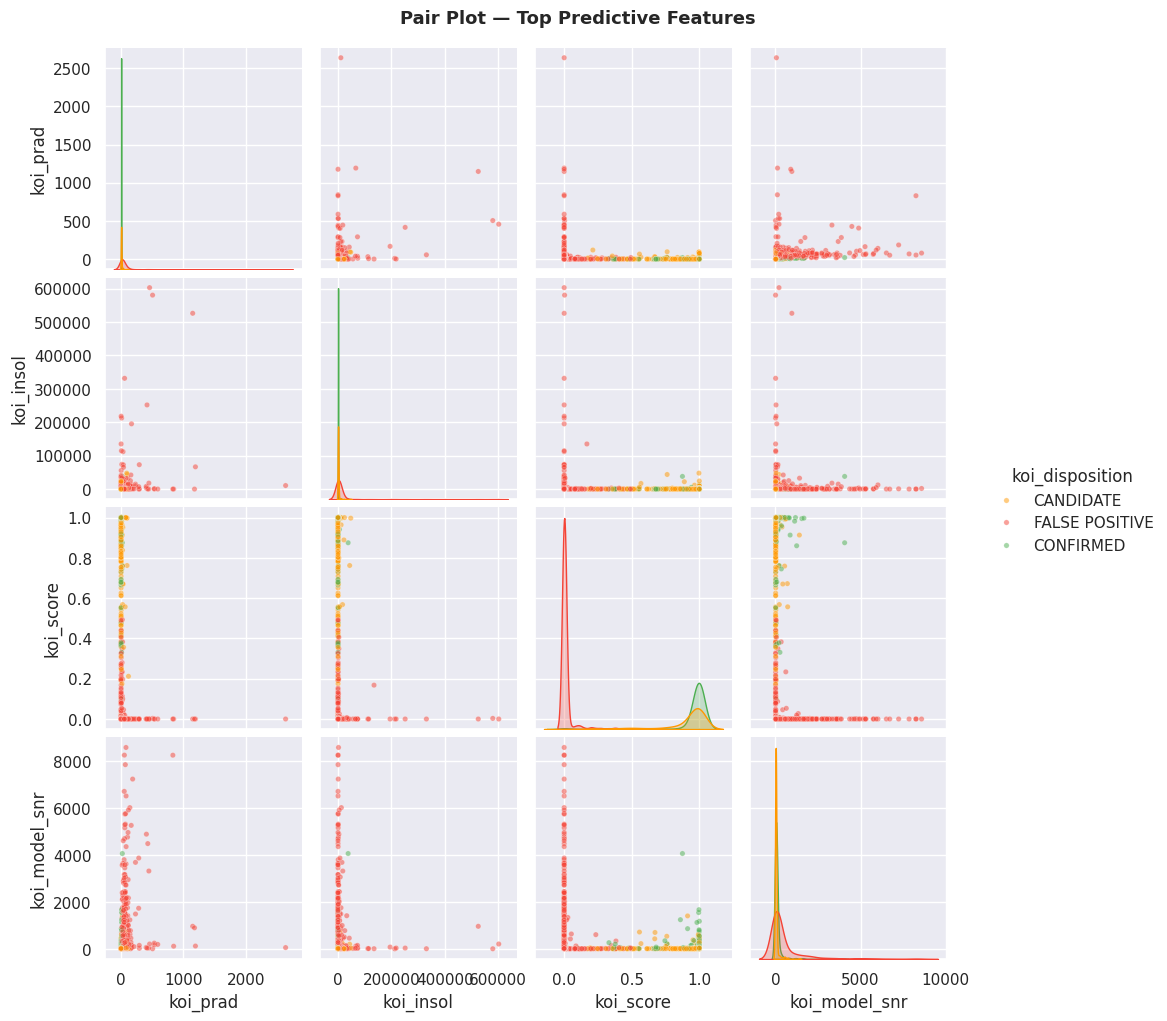

In [ ]:
top4 = ['koi_prad', 'koi_insol', 'koi_score', 'koi_model_snr', TARGET]
pair_df = df[top4].dropna().sample(n=min(1500, len(df)), random_state=42)

g = sns.pairplot(
    pair_df, hue=TARGET,
    palette = {'CONFIRMED': '#4CAF50', 'FALSE POSITIVE': '#F44336', 'CANDIDATE' : '#FF9800'},
    plot_kws = dict(alpha=0.5, s=15),
    diag_kind='kde'
)

g.figure.suptitle('Pair Plot — Top Predictive Features', y=1.02, fontsize=13, fontweight='bold')
plt.savefig('p3_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

STREAMLIT DASHBOARD

In [ ]:
STREAMLIT_CODE = '''
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

# ---- PAGE CONFIGURATION -------
st.set_page_config(
  page_title = 'Kepler Exoplanet Search',
  page_icon = '🌎',
  layout = 'wide'
)

COLOR_MAP = {
    'CONFIRMED': '#4CAF50',
    'FALSE POSITIVE': '#F44336',
    'CANDIDATE': '#FF9800'
}

# ---- LOAD DATA -----------------
@st.cache_data
def load_data():
  df = pd.read_csv('kepler_clean.csv')
  return df

df = load_data()

# ---- SIDEBAR CONTROLS ----------
st.sidebar.title("🌎 Kepler Explorer")
st.sidebar.markdown("Filter and explore the kepler exoplanet dataset.")

selected_classes = st.sidebar.multiselect(
  "Disposition classes",
  options = ["CONFIRMED", "FALSE POSITIVE", "CANDIDATE"],
  default = ["CONFIRMED", "FALSE POSITIVE", "CANDIDATE"]
)

period_range = st.sidebar.slider(
  "Orbital period range (days)",
  min_value = 0.0,
  max_value = float(df["koi_period"].quantile(0.99)),   # FIX 1: typo 'quaantile' → 'quantile'
  value = (0.0, float(df["koi_period"].quantile(0.95)))
)

# FIX 2: radius_range slider was missing entirely — added it here
radius_range = st.sidebar.slider(
  "Planet radius range (Earth radii)",
  min_value = 0.0,
  max_value = float(df["koi_prad"].quantile(0.99)),
  value = (0.0, float(df["koi_prad"].quantile(0.95)))
)

x_axis = st.sidebar.selectbox(
  "X axis (scatter plot)",
  ["koi_period", "koi_prad", "koi_teq", "koi_insol", "koi_model_snr", "koi_score"],
  index = 0
)

y_axis = st.sidebar.selectbox(
  "Y axis (scatter plot)",
  ["koi_prad", "koi_period", "koi_teq", "koi_insol", "koi_model_snr", "koi_score"],
  index = 0
)

# ---- Filter Data ------------
filtered = df[
    df["koi_disposition"].isin(selected_classes) &
    df["koi_period"].between(*period_range) &
    df["koi_prad"].between(*radius_range)
]

# ---- Header --------------------
st.title("🪐 Kepler Exoplanet Search Results — Explorer")
st.markdown(f"Showing **{len(filtered):,}** of **{len(df):,}** objects")

# ---- Metric row ------------------
col1, col2, col3, col4 = st.columns(4)
col1.metric("✅ Confirmed",       len(filtered[filtered["koi_disposition"] == "CONFIRMED"]))
col2.metric("❌ False Positives", len(filtered[filtered["koi_disposition"] == "FALSE POSITIVE"]))
col3.metric("🔍 Candidates",      len(filtered[filtered["koi_disposition"] == "CANDIDATE"]))
col4.metric("Avg. Planet Radius", f'{filtered["koi_prad"].mean():.2f} R⊕')  # FIX 3: nested quotes fixed

st.markdown("---")

# ---- Scatter plot -----------------------------------------
col_a, col_b = st.columns([2, 1])

with col_a:
    st.subheader(f"{x_axis} vs {y_axis}")
    fig_scatter = px.scatter(
        filtered, x=x_axis, y=y_axis,
        color="koi_disposition",
        color_discrete_map=COLOR_MAP,
        hover_data=["koi_teq", "koi_insol", "koi_score"],
        log_x=True, log_y=True,
        opacity=0.6, template="plotly_dark",
        labels={"koi_disposition": "Disposition"}
    )
    fig_scatter.update_traces(marker=dict(size=4))
    st.plotly_chart(fig_scatter, use_container_width=True)

with col_b:
    st.subheader("Class breakdown")
    counts = filtered["koi_disposition"].value_counts().reset_index()
    counts.columns = ["Disposition", "Count"]
    fig_pie = px.pie(counts, values="Count", names="Disposition",
                     color="Disposition", color_discrete_map=COLOR_MAP,
                     template="plotly_dark")
    st.plotly_chart(fig_pie, use_container_width=True)

# ---- Distribution plot --------------------------------------
st.subheader("Feature distribution by class")
feat = st.selectbox(
    "Select feature",
    ["koi_prad", "koi_period", "koi_teq", "koi_insol",
     "koi_model_snr", "koi_score", "koi_duration", "koi_depth"]
)

# FIX 4: same invisible bar bug as phase 3 — use go.Bar with manual bins for log features
if feat in ["koi_prad", "koi_period", "koi_insol"]:
    plot_df = filtered[[feat, "koi_disposition"]].dropna()
    plot_df = plot_df[plot_df[feat] > 0]
    if len(plot_df) > 0:
        bins = np.logspace(
            np.log10(plot_df[feat].min()),
            np.log10(plot_df[feat].max()),
            61
        )
        fig_hist = go.Figure()
        for disposition, color in COLOR_MAP.items():
            subset = plot_df[plot_df["koi_disposition"] == disposition][feat]
            counts_hist, edges = np.histogram(subset, bins=bins)
            fig_hist.add_trace(go.Bar(
                x=edges[:-1], y=counts_hist,
                name=disposition, marker_color=color,
                opacity=0.75, width=np.diff(edges), offset=0
            ))
        fig_hist.update_layout(
            barmode='overlay', bargap=0,
            xaxis=dict(title=feat + ' (log scale)', type='log'),
            yaxis_title='Count',
            template='plotly_dark',
            legend_title='Disposition'
        )
else:
    fig_hist = px.histogram(
        filtered, x=feat, color="koi_disposition",
        color_discrete_map=COLOR_MAP, barmode="overlay",
        opacity=0.7, nbins=60,
        template="plotly_dark",
        labels={"koi_disposition": "Disposition"}
    )
st.plotly_chart(fig_hist, use_container_width=True)

# ---- Correlation heatmap ------------------------------------
st.subheader("Correlation heatmap")
key_feats = ["koi_period", "koi_prad", "koi_teq", "koi_insol",
             "koi_model_snr", "koi_steff", "koi_slogg",
             "koi_srad", "koi_score", "koi_depth"]
corr = filtered[key_feats].corr().round(2)
fig_heat = go.Figure(go.Heatmap(
    z=corr.values, x=corr.columns.tolist(), y=corr.columns.tolist(),
    colorscale="RdBu_r", zmid=0,
    text=corr.values, texttemplate="%{text}", textfont={"size": 9}
))
fig_heat.update_layout(template="plotly_dark", height=500)
st.plotly_chart(fig_heat, use_container_width=True)

# ---- Raw data table -----------------------------------------
with st.expander("📄 View filtered data table"):
    st.dataframe(filtered.reset_index(drop=True), use_container_width=True)
'''

In [ ]:
with open('kepler_dashboard.py', 'w') as f:
  f.write(STREAMLIT_CODE)

In [ ]:
print("\n✅ Phase 3 complete.")
print("   Static charts : p3_pairplot.png")
print("   Interactive   : p3_scatter_radius_period.html")
print("                   p3_histogram_radius.html")
print("                   p3_boxplots_interactive.html")
print("                   p3_correlation_heatmap.html")
print("   Dashboard     : kepler_dashboard.py")
print("\n   To launch dashboard:")
print("\n Launch anaconda navigator, change directory where your code is")
print("   $ streamlit run kepler_dashboard.py")


✅ Phase 3 complete.
   Static charts : p3_pairplot.png
   Interactive   : p3_scatter_radius_period.html
                   p3_histogram_radius.html
                   p3_boxplots_interactive.html
                   p3_correlation_heatmap.html
   Dashboard     : kepler_dashboard.py

   To launch dashboard:

 Launch anaconda navigator, change directory where your code is
   $ streamlit run kepler_dashboard.py
